In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Для Prophet
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# Для метрик
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

print("Все библиотеки успешно импортированы")

Importing plotly failed. Interactive plots will not work.


Все библиотеки успешно импортированы


In [3]:
df_opzh = pd.read_excel('../../общая_ОПЖ (2).xlsx')
df_skr = pd.read_excel('../../общая_СКР (2).xlsx')

In [ ]:
# функция для удаления всех видов пробелов
def remove_all_spaces(value):
    if isinstance(value, str):
        # Удаляем все виды пробелов: обычные, неразрывные
        cleaned = ''.join(value.split())
        # Пробуем преобразовать к числу
        try:
            # Проверяем, является ли результат числом
            if cleaned.replace('.', '').replace(',', '').isdigit():
                # Заменяем запятую на точку для преобразования в float
                cleaned = cleaned.replace(',', '.')
                return float(cleaned) if '.' in cleaned else int(cleaned)
            else:
                return value
        except (ValueError, AttributeError):
            return value
    return value

# Применяем ко всем столбцам
df_opzh = df_opzh.applymap(remove_all_spaces)
df_skr = df_skr.applymap(remove_all_spaces)

print("\nПосле очистки данных:")
print("Типы данных в df_opzh:")
print(df_opzh.dtypes)
print("\nПервые 5 строк df_opzh:")
print(df_opzh.head())


После очистки данных:
Типы данных в df_opzh:
Регион                                                       object
Год                                                           int64
ОПЖ                                                         float64
Численность населения                                         int64
Число умерших                                                 int64
Общая численность инвалидов                                   int64
Кол-во преступлений                                         float64
Валовой региональный продукт на душу населения (ОКВЭД 2)    float64
Величина прожиточного минимума                              float64
Уровень бедности                                            float64
Средняя ЗП                                                    int64
Численность врачей всех специальностей                        int64
Число больничных организаций на конец отчетного года          int64
Число санаторно-курортных организаций                         int64
Мл

In [ ]:
def prepare_data_for_prophet(df, value_col, region_col='Регион', year_col='Год'):
    """Подготовка данных для Prophet — ОСТАВЛЯЕМ РЕГИОН"""
    df_prophet = df.copy()
    
    # Создаем столбец даты
    df_prophet['ds'] = pd.to_datetime(df_prophet[year_col].astype(str) + '-01-01')
    df_prophet['y'] = df_prophet[value_col]
    
    return df_prophet[['Регион', 'ds', 'y']]

In [6]:
# Функция для стандартизации названий регионов
def standardize_region_names(df):
    """Стандартизация названий регионов"""
    df_clean = df.copy()
    
    # Создаем словарь замен
    replacements = {
        'Ненецкий авт.округ': 'Ненецкий автономный округ',
        'Hенецкий авт.округ': 'Ненецкий автономный округ',  # латинская H
        '  Ненецкий автономный округ': 'Ненецкий автономный округ',
        
        'Ямало-Ненецкий авт.округ': 'Ямало-Ненецкий автономный округ',
        'Ямало-Hенецкий авт.округ': 'Ямало-Ненецкий автономный округ',  # латинская H
        '  Ямало-Ненецкий автономный округ': 'Ямало-Ненецкий автономный округ',
        
        'Ханты-Мансийский авт.округ-Югра': 'Ханты-Мансийский автономный округ - Югра',
        '  Ханты-Мансийский автономный округ - Югра': 'Ханты-Мансийский автономный округ - Югра',
        
        'Республика Татарстан(Татарстан)': 'Республика Татарстан',
        'Чувашская Республика(Чувашия)': 'Чувашская Республика',
        'Республика Северная Осетия- Алания': 'Республика Северная Осетия-Алания',
        
        'Oмская область': 'Омская область',  # латинская O
        'Hижегородская область': 'Нижегородская область',  # латинская H
        
        'г. Севастополь': 'г.Севастополь',
        'г.Москва': 'г.Москва',
        'г.Санкт-Петербург': 'г.Санкт-Петербург',
        
        'Чукотский авт.округ': 'Чукотский автономный округ',
        'Чукотский автономный округ': 'Чукотский автономный округ'
    }
    
    # Применяем замены
    df_clean['Регион'] = df_clean['Регион'].replace(replacements)
    
    # Удаляем лишние пробелы
    df_clean['Регион'] = df_clean['Регион'].str.strip()
    
    return df_clean

# Применяем стандартизацию к обоим датасетам
print("Стандартизация названий регионов...")
df_opzh_clean = standardize_region_names(df_opzh)
df_skr_clean = standardize_region_names(df_skr)

print(f"Уникальных регионов в ОПЖ после очистки: {df_opzh_clean['Регион'].nunique()}")
print(f"Уникальных регионов в СКР после очистки: {df_skr_clean['Регион'].nunique()}")

# Проверяем общие регионы
common_regions = set(df_opzh_clean['Регион']).intersection(set(df_skr_clean['Регион']))
print(f"Общих регионов между датасетами: {len(common_regions)}")

Стандартизация названий регионов...
Уникальных регионов в ОПЖ после очистки: 85
Уникальных регионов в СКР после очистки: 85
Общих регионов между датасетами: 85


In [7]:

# Подготовка данных для ОПЖ
df_opzh_prophet = prepare_data_for_prophet(df_opzh_clean, 'ОПЖ')
df_skr_prophet = prepare_data_for_prophet(df_skr_clean, 'СКР')

print("Данные подготовлены для Prophet")

Данные подготовлены для Prophet


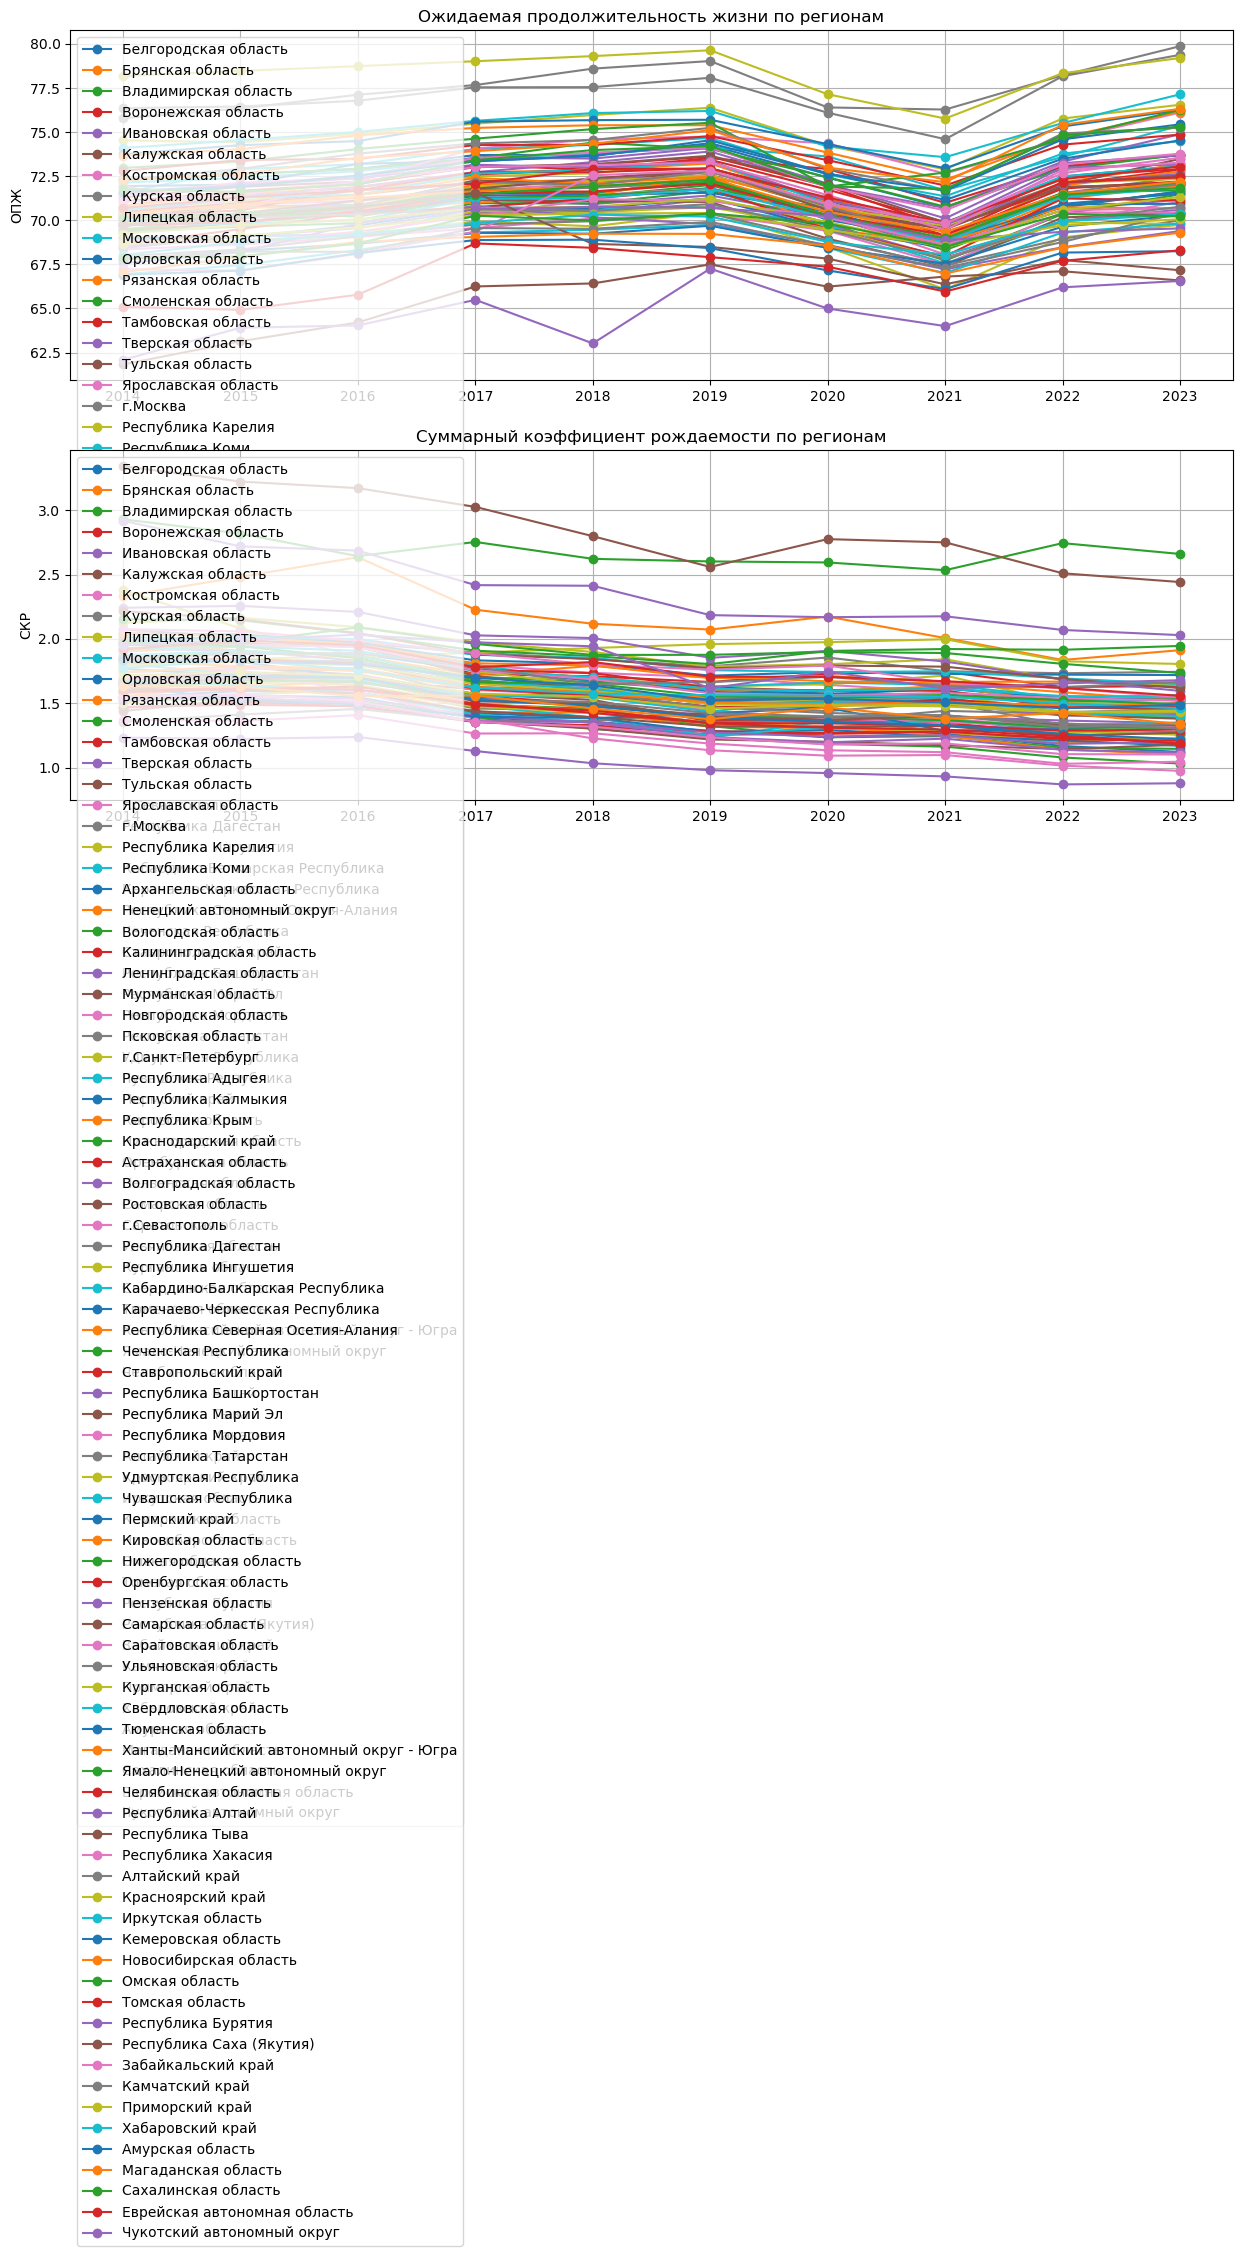

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ОПЖ по регионам
regions = df_opzh_prophet['Регион'].unique() 
for region in regions:
    region_data = df_opzh_prophet[df_opzh_prophet['Регион'] == region]
    axes[0].plot(region_data['ds'], region_data['y'], marker='o', label=region)

axes[0].set_title('Ожидаемая продолжительность жизни по регионам')
axes[0].set_ylabel('ОПЖ')
axes[0].legend()
axes[0].grid(True)

# СКР по регионам
for region in regions:
    region_data = df_skr_prophet[df_skr_prophet['Регион'] == region]
    axes[1].plot(region_data['ds'], region_data['y'], marker='o', label=region)

axes[1].set_title('Суммарный коэффициент рождаемости по регионам')
axes[1].set_ylabel('СКР')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
def train_prophet_models(df, target_col='y', horizon=2):
    regions = df['Регион'].unique()
    models = {}
    forecasts = {}
    metrics = {}
    
    for region in regions:
        print(f"\n--- Обучение для региона: {region} ---")
        region_data = df[df['Регион'] == region].copy().sort_values('ds')
        
        print(f"Доступные годы: {sorted(region_data['ds'].dt.year.unique())}")
        print(f"Значения: {region_data['y'].tolist()}")
        
        if len(region_data) < 5:
            print("Слишком мало данных, пропускаем")
            continue
            
        # Разделение на train/test
        train_data = region_data.iloc[:-2] if len(region_data) >= 5 else region_data.iloc[:-1]
        test_data = region_data.iloc[-2:] if len(region_data) >= 5 else region_data.iloc[-1:]
        
        print(f"Train годы: {sorted(train_data['ds'].dt.year.unique())}")
        print(f"Test годы: {sorted(test_data['ds'].dt.year.unique())}")
        
        try:
            # Подготовка данных для Prophet
            train_for_prophet = train_data[['ds', 'y']].copy()
            
            # Настройка модели для демографических данных
            model = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                changepoint_prior_scale=0.05,  # Меньше = более плавные изменения
                seasonality_prior_scale=10.0,
                changepoint_range=0.8,  # 80% данных для точек изменения
                interval_width=0.95
            )
            
            model.fit(train_for_prophet)
            
            # Прогноз на будущее
            last_year = region_data['ds'].dt.year.max()
            future_years = [last_year + i for i in range(1, horizon + 1)]
            future_dates = pd.to_datetime([f'{y}-01-01' for y in future_years])
            future_df = pd.DataFrame({'ds': future_dates})
            
            future_forecast = model.predict(future_df)
            
            # Оценка на тестовых данных
            test_forecast = model.predict(test_data[['ds']])
            y_true = test_data['y'].values
            y_pred = test_forecast['yhat'].values
            
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            metrics[region] = {'RMSE': rmse, 'MAE': mae}
            
            print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}")
            print(f"Факт: {y_true}, Прогноз: {y_pred}")
            
            # Сохраняем модель и прогноз
            models[region] = model
            forecasts[region] = future_forecast
            
        except Exception as e:
            print(f"Ошибка: {e}")
    
    return models, forecasts, metrics

In [12]:
def plot_forecasts(forecasts, df, target_name, region, models=None):
    """Улучшенная визуализация с диагностикой"""
    if region not in forecasts:
        print(f"Нет прогноза для региона: {region}")
        return
        
    # Фактические данные
    fact_data = df[df['Регион'] == region].copy().sort_values('ds')
    fact_data['Год'] = fact_data['ds'].dt.year
    
    # Прогноз
    forecast = forecasts[region].copy()
    forecast['Год'] = forecast['ds'].dt.year
    
    print(f"\n=== АНАЛИЗ {target_name} - {region} ===")
    print("Фактические данные:")
    for _, row in fact_data.iterrows():
        print(f"  {row['Год']}: {row['y']:.2f}")
    
    print("Прогноз на будущее:")
    for _, row in forecast.iterrows():
        print(f"  {row['Год']}: {row['yhat']:.2f}")
    
    # Построение графика
    plt.figure(figsize=(12, 6))
    
    # Фактические данные
    plt.plot(fact_data['Год'], fact_data['y'], 'bo-', 
             markersize=8, linewidth=2, label='Фактические данные')
    
    # Прогноз
    plt.plot(forecast['Год'], forecast['yhat'], 'ro-', 
             markersize=8, linewidth=2, label='Прогноз')
    
    # Доверительный интервал
    plt.fill_between(forecast['Год'],
                    forecast['yhat_lower'],
                    forecast['yhat_upper'],
                    color='red', alpha=0.2, label='Доверительный интервал')
    
    plt.title(f'{target_name} - {region}\n(Синие точки - факт, Красные - прогноз)', fontsize=14)
    plt.xlabel('Год', fontsize=12)
    plt.ylabel(target_name, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# Сначала проверим данные
print("=== ПРОВЕРКА ДАННЫХ ===")
print("df_opzh_clean columns:", df_opzh_clean.columns.tolist())
print("df_skr_clean columns:", df_skr_clean.columns.tolist())

# подготовка данных
df_opzh_prophet = prepare_data_for_prophet(df_opzh_clean, 'ОПЖ')
df_skr_prophet = prepare_data_for_prophet(df_skr_clean, 'СКР')

print("После подготовки:")
print("df_opzh_prophet sample:")
print(df_opzh_prophet.head())
print("\ndf_skr_prophet sample:")
print(df_skr_prophet.head())

# Обучение улучшенными моделями
print("\n=== ОБУЧЕНИЕ УЛУЧШЕННЫХ МОДЕЛЕЙ ===")
models_opzh, forecasts_opzh, metrics_opzh = train_prophet_models(df_opzh_prophet)
models_skr, forecasts_skr, metrics_skr = train_prophet_models(df_skr_prophet)

# Визуализация
print("\n=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===")
for region in list(models_opzh.keys())[:5]:
    plot_forecasts(forecasts_opzh, df_opzh_prophet, 'ОПЖ', region, models_opzh)

for region in list(models_skr.keys())[:5]:
    plot_forecasts(forecasts_skr, df_skr_prophet, 'СКР', region, models_skr)

: 

In [ ]:
# Сохранение финальных предсказаний 

def save_final_predictions(forecasts_dict, original_df, target_name, output_file):
    """
    forecasts_dict: словарь {регион: прогноз от Prophet}
    original_df: исходный df с реальными годами (нужен для последнего года)
    target_name: 'ОПЖ' или 'СКР'
    """
    results = []
    
    for region, forecast in forecasts_dict.items():
        # прогноз от Prophet — уже содержит 'ds' и 'yhat'
        for _, row in forecast.iterrows():
            year = row['ds'].year
            pred = row['yhat']
            results.append({
                'Регион': region,
                'Год': year,
                target_name: None,
                'predictions': pred
            })
    
    result_df = pd.DataFrame(results)
    result_df.to_excel(output_file, index=False)
    print(f"Сохранено: {output_file} ({len(result_df)} строк)")

# Сохраняем
save_final_predictions(forecasts_opzh, df_opzh_prophet, 'ОПЖ', 'predictions_opzh.xlsx')
save_final_predictions(forecasts_skr, df_skr_prophet, 'СКР', 'predictions_skr.xlsx')

Сохранено: predictions_opzh.xlsx (170 строк)
Сохранено: predictions_skr.xlsx (170 строк)
